### Exercise 3 - Preparing Real-World Data for a Neural Network

A - Get to know the data

1. Download the Spaceship Titanic dataset

In [ ]:
from pathlib import Path
import kagglehub

data_dir = Path("./data")
data_dir.mkdir(parents=True, exist_ok=True)

dataset_path = kagglehub.competition_download(
    "spaceship-titanic",
    output_dir=str(data_dir),
)

print("Dataset downloaded to:", dataset_path)
print("Files:", [file.name for file in data_dir.iterdir()])

2. Describe the goal of the dataset: what does the ``Transported`` column represent? What is the class balance between the two labels?

    **A:** The goal of the Spaceship Titanic dataset is to predict whether a passenger was transported to an alternate dimension after the spaceship collided with a spacetime anomaly. The `Transported` column is the binary target variable:

    - `True`: the passenger was transported.
    - `False`: the passenger was not transported.

    The training dataset contains 8,693 passengers. Its class distribution is:

    | Transported | Count | Percentage |
    |---|---:|---:|
    | `True` | 4,378 | 50.36% |
    | `False` | 4,315 | 49.64% |

    Therefore, the dataset is very well balanced, with only a small difference of 63 passengers between the two classes. No major class-imbalance correction is necessary.

In [4]:
import pandas as pd

train_df = pd.read_csv(data_dir / "train.csv")

class_counts = train_df["Transported"].value_counts()
class_percentages = (
    train_df["Transported"]
    .value_counts(normalize=True)
    .mul(100)
)

class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages,
})

print(class_balance)

             Count  Percentage
Transported                   
True          4378   50.362361
False         4315   49.637639


3. List the features, separating numerical from categorical.

    **A:** The dataset contains the following input features:

    Numerical features

    - `Age`: passenger's age.
    - `RoomService`: amount spent on room service.
    - `FoodCourt`: amount spent at the food court.
    - `ShoppingMall`: amount spent at the shopping mall.
    - `Spa`: amount spent at the spa.
    - `VRDeck`: amount spent on the virtual-reality deck.

    Categorical features

    - `HomePlanet`: passenger's planet of origin.
    - `CryoSleep`: whether the passenger was placed in suspended animation.
    - `Cabin`: cabin number in the format `deck/number/side`.
    - `Destination`: passenger's destination planet.
    - `VIP`: whether the passenger paid for VIP service.

    Identifier and text columns

    - `PassengerId`: unique passenger identifier in the format `group_number/passenger_number`.
    - `Name`: passenger's name.

    `PassengerId` and `Name` are not ordinary categorical features because most of their values are unique. However, useful information can be extracted from them, such as the passenger's group from `PassengerId` or family information from `Name`.

    The `Transported` column is the target and is therefore not included among the input features.

4. Build a table of missing values per column, in absolute count and in percentage.

In [5]:
missing_values = (
    pd.DataFrame({
        "Missing values": train_df.isna().sum(),
        "Missing percentage": train_df.isna().mean() * 100,
    })
    .sort_values("Missing values", ascending=False)
    .rename_axis("Column")
    .reset_index()
)

missing_values["Missing percentage"] = (
    missing_values["Missing percentage"].round(2)
)

display(missing_values)

,Column,Missing values,Missing percentage
0,CryoSleep,217,2.50
1,ShoppingMall,208,2.39
2,VIP,203,2.34
3,HomePlanet,201,2.31
4,Name,200,2.30
5,Cabin,199,2.29
6,VRDeck,188,2.16
7,Spa,183,2.11
8,FoodCourt,183,2.11
9,Destination,182,2.09


5. For the spending columns, report mean, median, and maximum. Compare mean and median: what does that difference tell you about the spread and the skewness of those distributions?

In [6]:
spending_columns = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck",
]

spending_summary = (
    train_df[spending_columns]
    .agg(["mean", "median", "max"])
    .T
    .rename(columns={
        "mean": "Mean",
        "median": "Median",
        "max": "Maximum",
    })
    .round(2)
)

display(spending_summary)

,Mean,Median,Maximum
RoomService,224.69,0.0,14327.0
FoodCourt,458.08,0.0,29813.0
ShoppingMall,173.73,0.0,23492.0
Spa,311.14,0.0,22408.0
VRDeck,304.85,0.0,24133.0


All five spending features have a median of zero, indicating that at least half of the passengers did not spend money in each respective category. However, their means are considerably greater than zero, and their maximum values are extremely high.

The large difference between the mean and median indicates that the distributions are strongly right-skewed: most passengers spent little or nothing, while a relatively small number of passengers spent very large amounts. These large values pull the mean upward.

The wide range between zero and the maximum values also indicates substantial spread and the presence of extreme values. `FoodCourt` has the highest mean and maximum spending among the five features.

The mean–median difference primarily indicates skewness rather than measuring spread directly. Measures such as the standard deviation or interquartile range would be needed to quantify the spread more precisely.

B - Split before you transform

In [7]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=["Transported"])
y = train_df["Transported"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

X_train: (6954, 13)
X_test: (1739, 13)
y_train: (6954,)
y_test: (1739,)

Training target distribution:
Transported
0    0.496405
1    0.503595
Name: proportion, dtype: float64

Test target distribution:
Transported
0    0.496262
1    0.503738
Name: proportion, dtype: float64


Explain, in two or three sentences, why this split comes before imputation and scaling.

**A:** The split must be performed before imputation and scaling so that these preprocessing steps are fitted using only the training data. Otherwise, information from the test set could influence the imputed values and scaling parameters, causing data leakage and producing an overly optimistic evaluation of the model.

C - Preprocess 

1. Missing data

In [ ]:
from sklearn.impute import SimpleImputer

numerical_features = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck",
]

categorical_features = [
    "HomePlanet",
    "CryoSleep",
    "Cabin",
    "Destination",
    "VIP",
    "PassengerId",
    "Name",
]

numerical_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

# Fit only on the training set
X_train_imputed[numerical_features] = (
    numerical_imputer.fit_transform(X_train[numerical_features])
)

X_train_imputed[categorical_features] = (
    categorical_imputer.fit_transform(X_train[categorical_features])
)

# Apply the learned values to the test set
X_test_imputed[numerical_features] = (
    numerical_imputer.transform(X_test[numerical_features])
)

X_test_imputed[categorical_features] = (
    categorical_imputer.transform(X_test[categorical_features])
)

print("Missing values in training set:", X_train_imputed.isna().sum().sum(),)
print("Missing values in test set:", X_test_imputed.isna().sum().sum(),)

Missing values in training set: 0
Missing values in test set: 0


For the numerical features, missing values were replaced with the median calculated from the training set. The median was chosen because the spending variables are strongly right-skewed and contain extreme values, making it more robust than the mean.

For categorical features, missing values were replaced with the most frequent category in each training column. This strategy preserves valid categories and is reasonable because the proportion of missing values is small.

Both imputers were fitted exclusively on the training set and then applied to the test set. This prevents information from the test set from influencing preprocessing and avoids data leakage.

2. Categorical features

In [14]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP",
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    dtype=int,
)

# Fit only on the training set
train_encoded_array = encoder.fit_transform(
    X_train_imputed[categorical_features]
)

# Apply the same encoding to the test set
test_encoded_array = encoder.transform(
    X_test_imputed[categorical_features]
)

encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

train_encoded_categories = pd.DataFrame(
    train_encoded_array,
    columns=encoded_feature_names,
    index=X_train_imputed.index,
)

test_encoded_categories = pd.DataFrame(
    test_encoded_array,
    columns=encoded_feature_names,
    index=X_test_imputed.index,
)

display(train_encoded_categories.head())

,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_False,CryoSleep_True,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_False,VIP_True
3600,1,0,0,1,0,0,0,1,1,0
1262,1,0,0,0,1,0,0,1,1,0
8612,1,0,0,1,0,0,1,0,1,0
5075,0,1,0,0,1,1,0,0,1,0
4758,1,0,0,1,0,0,0,1,1,0


In [15]:
X_train_encoded = (
    X_train_imputed
    .drop(columns=categorical_features)
    .join(train_encoded_categories)
)

X_test_encoded = (
    X_test_imputed
    .drop(columns=categorical_features)
    .join(test_encoded_categories)
)

print("Training shape:", X_train_encoded.shape)
print("Test shape:", X_test_encoded.shape)

print("\nEncoded columns:")
print(encoded_feature_names)

Training shape: (6954, 19)
Test shape: (1739, 19)

Encoded columns:
['HomePlanet_Earth' 'HomePlanet_Europa' 'HomePlanet_Mars'
 'CryoSleep_False' 'CryoSleep_True' 'Destination_55 Cancri e'
 'Destination_PSO J318.5-22' 'Destination_TRAPPIST-1e' 'VIP_False'
 'VIP_True']


`HomePlanet`, `CryoSleep`, `Destination`, and `VIP` were converted to numerical format using one-hot encoding. This method creates one binary column for each category and does not impose an artificial numerical order on the categories.

The encoder was fitted only on the training set and then applied to the test set. The option `handle_unknown="ignore"` ensures that a category found in the test set but not in the training set does not cause an error. In that case, all encoded columns associated with the original feature are set to zero for that observation, while the test set keeps exactly the same columns and column order as the training set.

3. Feature engineering

In [16]:
columns_to_drop = [
    "Cabin",
    "Name",
    "PassengerId",
]

def engineer_features(df):
    df = df.copy()

    df["TotalSpend"] = df[spending_columns].sum(axis=1)

    df = df.drop(columns=columns_to_drop)

    return df


X_train_engineered = engineer_features(X_train_encoded)
X_test_engineered = engineer_features(X_test_encoded)

print("Training shape:", X_train_engineered.shape)
print("Test shape:", X_test_engineered.shape)

X_train_engineered.head()

Training shape: (6954, 17)
Test shape: (1739, 17)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_False,CryoSleep_True,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_False,VIP_True,TotalSpend
3600,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,1,0,0,0,1,1,0,0.0
1262,17.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,1,0,0,1,1,0,0.0
8612,35.0,0.0,0.0,0.0,0.0,0.0,1,0,0,1,0,0,1,0,1,0,0.0
5075,26.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,1,1,0,0,1,0,0.0
4758,13.0,0.0,0.0,60.0,1.0,5147.0,1,0,0,1,0,0,0,1,1,0,5208.0


4. Heavy tails

In [17]:
import numpy as np
import matplotlib.pyplot as plt

spending_columns.append("TotalSpend")

X_train_before_log = X_train_engineered.copy()

X_train_log = X_train_engineered.copy()
X_test_log = X_test_engineered.copy()

# Apply log(1 + x) using parameters from neither dataset
X_train_log[spending_columns] = np.log1p(
    X_train_log[spending_columns]
)

X_test_log[spending_columns] = np.log1p(
    X_test_log[spending_columns]
)

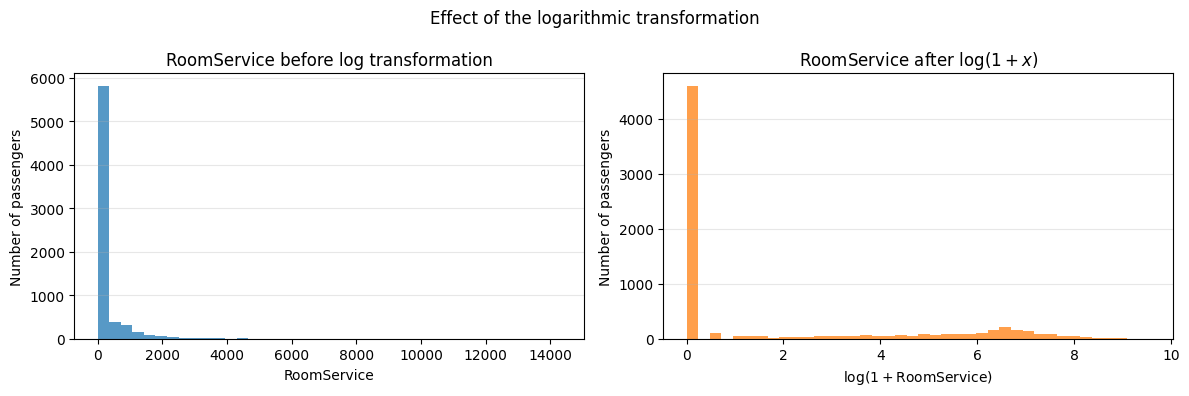

In [21]:
feature = "RoomService"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    X_train_before_log[feature],
    bins=40,
    color="tab:blue",
    alpha=0.75,
)

axes[0].set_title(f"{feature} before log transformation")
axes[0].set_xlabel(feature)
axes[0].set_ylabel("Number of passengers")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(
    X_train_log[feature],
    bins=40,
    color="tab:orange",
    alpha=0.75,
)

axes[1].set_title(rf"{feature} after $\log(1+x)$")
axes[1].set_xlabel(rf"$\log(1+\mathrm{{{feature}}})$")
axes[1].set_ylabel("Number of passengers")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Effect of the logarithmic transformation")
fig.tight_layout()
fig.savefig("./figures/figure6.png", dpi=150)
plt.show()

The spending variables are strongly right-skewed: most passengers spent little or nothing, while a small number spent extremely large amounts. Applying the transformation

$$
x' = \log(1+x)
$$

compresses the extreme values and reduces the right skew while preserving zero values.

This helps a neural network with `tanh` because very large input values can produce large activations, pushing `tanh` into its saturated regions near −1 or 1. In these regions, its gradient is close to zero, which can slow down learning. The logarithmic transformation reduces the influence of extreme values and, after scaling, keeps more inputs in the sensitive region of `tanh`, where gradients are larger.

The logarithm alone does not place the features in the interval $[-1,1]$, so a scaling step is still necessary.

5. Scaling

In [25]:
from sklearn.preprocessing import MinMaxScaler

numerical_features_to_scale = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck",
    "TotalSpend",
]

X_train_scaled = X_train_log.copy()
X_test_scaled = X_test_log.copy()

scaler = MinMaxScaler(feature_range=(-1, 1), clip=True)

# Fit only on the training data
X_train_scaled[numerical_features_to_scale] = scaler.fit_transform(
    X_train_log[numerical_features_to_scale]
)

# Apply the same transformation to the test data
X_test_scaled[numerical_features_to_scale] = scaler.transform(
    X_test_log[numerical_features_to_scale]
)

In [26]:
train_range = (
    X_train_scaled[numerical_features_to_scale]
    .agg(["min", "max"])
    .T
    .rename(columns={
        "min": "Training minimum",
        "max": "Training maximum",
    })
)

test_range = (
    X_test_scaled[numerical_features_to_scale]
    .agg(["min", "max"])
    .T
    .rename(columns={
        "min": "Test minimum",
        "max": "Test maximum",
    })
)

range_report = train_range.join(test_range).round(4)

display(range_report)

,Training minimum,Training maximum,Test minimum,Test maximum
Age,-1.0,1.0,-1.0,0.9494
RoomService,-1.0,1.0,-1.0,0.8819
FoodCourt,-1.0,1.0,-1.0,0.9326
ShoppingMall,-1.0,1.0,-1.0,1.0000
Spa,-1.0,1.0,-1.0,0.9345
VRDeck,-1.0,1.0,-1.0,1.0000
TotalSpend,-1.0,1.0,-1.0,0.9527


Min-max normalization to the interval $[-1,1]$ was selected because this range is directly compatible with the output range of the `tanh` activation function. Keeping numerical inputs within this range reduces the chance of producing very large activations that push `tanh` into its saturated regions, where its gradients are close to zero.

The scaler was fitted only on the training set and then applied unchanged to the test set, preventing data leakage. After normalization, every numerical training feature has a minimum of $-1$ and a maximum of $1$. 

D - Verify and Visualize

1. **Figure 6:** histogram of one heavy-tailed feature before and after preprocessing;

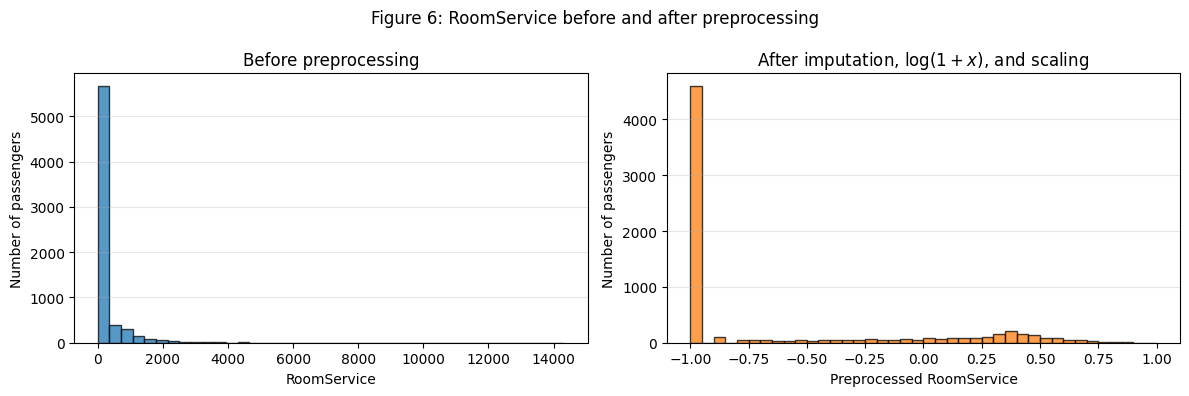

In [24]:
Path("./figures").mkdir(exist_ok=True)

feature = "RoomService"

before = X_train[feature].dropna()
after = X_train_scaled[feature]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before preprocessing
axes[0].hist(
    before,
    bins=40,
    color="tab:blue",
    alpha=0.75,
    edgecolor="black",
)

axes[0].set_title("Before preprocessing")
axes[0].set_xlabel("RoomService")
axes[0].set_ylabel("Number of passengers")
axes[0].grid(axis="y", alpha=0.3)

# After preprocessing
axes[1].hist(
    after,
    bins=40,
    color="tab:orange",
    alpha=0.75,
    edgecolor="black",
)

axes[1].set_title(r"After imputation, $\log(1+x)$, and scaling")
axes[1].set_xlabel("Preprocessed RoomService")
axes[1].set_ylabel("Number of passengers")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Figure 6: RoomService before and after preprocessing")
fig.tight_layout()
fig.savefig("./figures/figure6.png", dpi=150, bbox_inches="tight")

plt.show()

2. Final checks, explicitly reported: no remaining `NaN` values; the final shape of the feature matrix; the value range is compatible with `tanh`.

In [29]:
# 1. Check remaining Na remaining Na remaining NaN values
train_nan = X_train_scaled.isna().sum().sum()
test_nan = X_test_scaled.isna().sum().sum()

# 2. Check final shapes
train_shape = X_train_scaled.shape
test_shape = X_test_scaled.shape

# 3. Check global value ranges
train_values = X_train_scaled.to_numpy(dtype=float)
test_values = X_test_scaled.to_numpy(dtype=float)

train_min = train_values.min()
train_max = train_values.max()

test_min = test_values.min()
test_max = test_values.max()

print("Remaining NaN values:")
print(f"Training set: {train_nan}")
print(f"Test set: {test_nan}")

print("\nFinal feature matrix shapes:")
print(f"Training set: {train_shape}")
print(f"Test set: {test_shape}")

print("\nValue ranges:")
print(f"Training set: [{train_min:.3f}, {train_max:.3f}]")
print(f"Test set: [{test_min:.3f}, {test_max:.3f}]")

# Explicit validations
assert train_nan == 0, "The training set still contains NaN values."
assert test_nan == 0, "The test set still contains NaN values."
assert train_shape[1] == test_shape[1], "Train and test have different feature counts."
assert train_min >= -1 and train_max <= 1
assert test_min >= -1 and test_max <= 1

Remaining NaN values:
Training set: 0
Test set: 0

Final feature matrix shapes:
Training set: (6954, 17)
Test set: (1739, 17)

Value ranges:
Training set: [-1.000, 1.000]
Test set: [-1.000, 1.000]


3. In one paragraph: which of your preprocessing decisions do you think would most affect the network's training, and why?

    **A:** The logarithmic transformation and normalization of the numerical features would likely have the greatest effect on the network’s training. The spending variables originally contain highly skewed distributions and extreme values, which could dominate the optimization process and push `tanh` neurons into their saturated regions, where gradients become very small. Applying \(\log(1+x)\) reduces the influence of extreme values, while normalization to \([-1,1]\) places the features on comparable scales, helping the network maintain useful gradients and train more quickly and stably.